# Test linear model on all Time Series

In [7]:
from astropy.io import fits
from scipy.io import readsav
import numpy as np
import matplotlib.pyplot as plt

import torch  # to load PCA data

from tqdm import tqdm

import tools as t

## Load data

In [19]:
# loading spectra and time
path_data = '../data/sim_series/'  # directory where the files are saved
TS = 20  # time series used
data_spectra = []
for i in range(TS):  # files have the same name, only number changes
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series

In [ ]:
# Loading PCA scores and RVs for each TS
# Parameters

N = 3686  # timesteps
M = 20  # PCs

# Load data

scores = []
rv = []

for i in tqdm(range(TS)):

    scores_i = []
    rv_i = []
    
    for j in range(N):
        
        data = torch.load(f'../data/PCA/TS{i+1}/t_{j}.pt')

        scores_i.append(data['scores'].float())
        rv_i.append(torch.as_tensor(data['rv'], dtype=torch.float32))

    scores.append(np.array(
        torch.stack(scores_i)
        ))
    rv.append(np.array(
        torch.stack(rv_i)
        ))

scores = np.array(scores)
rv = np.array(rv)

print("Total X shape:", scores.shape)
print("Total y shape:", rv.shape)

  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_51990/3754810873.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{i+1}/t_{j}.pt')

Total X shape: (20, 3686, 20)
Total y shape: (20, 3686)


## Train using TS1

In [21]:
# do a linear model (y = I * X) to compare with the result from the neural network

# get the scores and RVs from the first TS
scores_0 = scores[0]
rv_true_0 = rv[0]

k = 20  # number of PCs used for the fit
scores_matrix_0 = np.array(scores_0)[:, :k]  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components

train_size = int(0.7 * N)

# separate the scores and RVs into sub samples
scores_train_0 = scores_matrix_0[:train_size]
scores_test_0  = scores_matrix_0[train_size:]

rv_true_train_0 = rv_true_0[:train_size]
rv_true_test_0 = rv_true_0[train_size:]

times_test = times[train_size:]

# training the linear model using all the scores

G = np.dot(scores_train_0.T, scores_train_0)
b = np.dot(scores_train_0.T, rv_true_train_0)
alpha = np.linalg.solve(G, b)

In [ ]:
# testing the model on the same TS
rv_pred_test_0  = np.dot(alpha, scores_test_0.T)  # predict
res_test_linear_0  = rv_true_test_0 - rv_pred_test_0  # calculate residuals
std_res_linear_0 = np.std(res_test_linear_0)

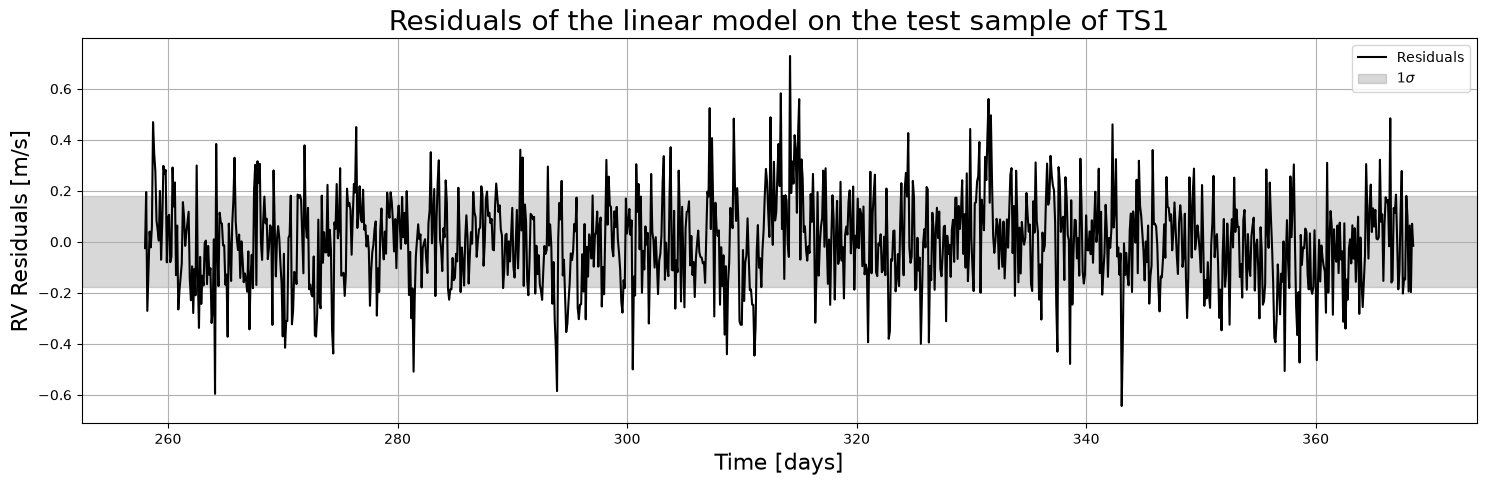

In [30]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Residuals of the linear model on the test sample of TS1', size=20)

ax.grid()
ax.plot(times_test, res_test_linear_0, color='k', label='Residuals')
ax.axhspan(-std_res_linear_0, std_res_linear_0, color='gray', alpha=.3, label=r'$1\sigma$')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

In [32]:
print(f'The standard deviation of the residuals is {std_res_linear_0:.2f} m/s.')

The standard deviation of the residuals is 0.18 m/s.


## Testing the model on the other TS

In [ ]:
rv_pred = []
res = []
res_sigma = []

for i in range(len(scores)):

    scores_i = scores[i]
    rv_true_i = rv[i]
    
    rv_pred_i = np.dot(alpha, scores_i.T)
    res_i = rv_true_i - rv_pred_i
    
    rv_pred.append(rv_pred_i)
    res.append(res_i)
    res_sigma.append(np.std(res_i))  # need error bars on this, predict by chunks (?)

rv_pred = np.array(rv_pred)
res = np.array(res)
res_sigma = np.array(res_sigma)

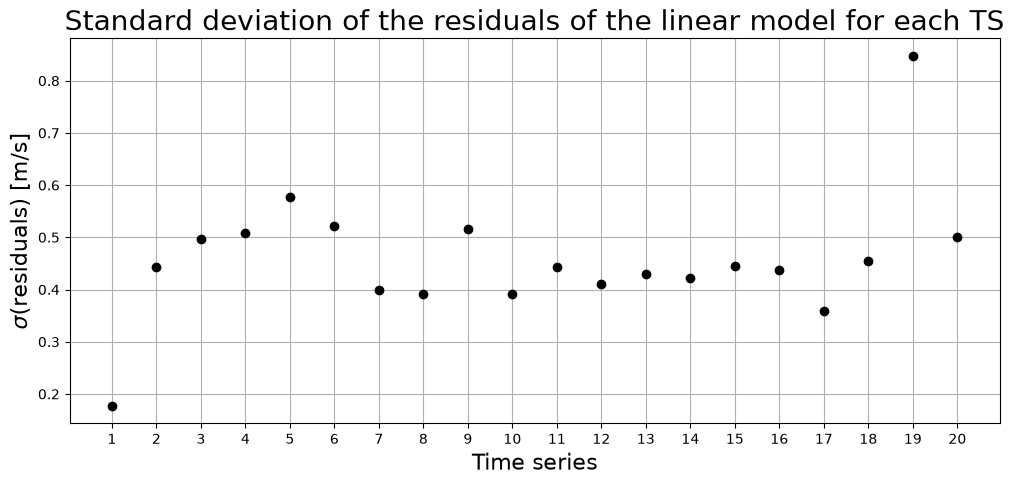

In [42]:
ts_arr = np.linspace(1, TS, TS)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Standard deviation of the residuals of the linear model for each TS', size=20)

ax.grid()
ax.scatter(ts_arr, res_sigma, color='k', zorder=2)

ax.set_xlabel('Time series', size=16)
ax.set_ylabel(r'$\sigma$(residuals) [m/s]', size=16)

ax.set_xticks(ts_arr)

plt.show()